##### Softmax regression is a generalization of logistic regression for multiclass classification (target has more than 2 classes). 
#####   - The model predicts logits(raw class scores) for each class.
#####   - Softmax then converts these scores into relative probabilities that sum to 1.
#####   - The predicted class is the one with the highest probability: (argmax(p)).

In [29]:
import numpy as np
import matplotlib.pyplot as plt

### Step 1 : Create a simple 3-class 2D dataset

In [30]:
np.random.seed(0)

# three clusters in 2D 
X0 = np.random.randn(50,2) + np.array([0,0])
X1 = np.random.randn(50,2) + np.array([3,3])
X2 = np.random.randn(50,2) + np.array([0,4])

X = np.vstack([X0,X1,X2])
y = np.array([0]*50 + [1]*50 + [2]*50)

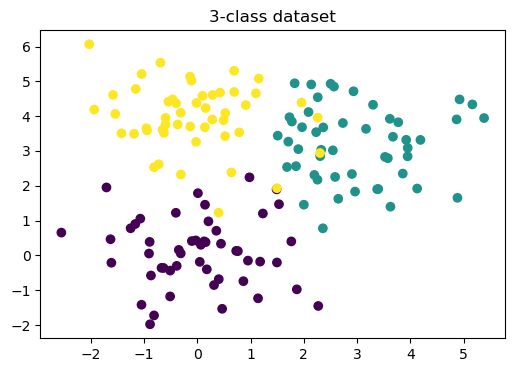

In [31]:
# Quick plot of the dataset 
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1],c=y)
plt.title("3-class dataset")
plt.show()

### Step 2 : Softmax (numerically stable)

Softmax uses exp(logits), and when the logit is very large number it causes overflow problem.
To prevent this, maximum logit is subtracted in each row:
 - this keeps the largest value at 0
 - all other values become ≤ 0
   
So all the exponentials stay in safe range.

Softmax is shift-invariant : subtracring the same constant from all logits does not change the final probabilities.

In [32]:
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    Z_exp = np.exp(Z)
    return Z_exp / np.sum(Z_exp, axis=1, keepdims=True)

### Step 3 : One-hot encoding

In [33]:
def one_hot(y, num_classes):
    m = y.size
    Y = np.zeros((m,num_classes))
    Y[np.arange(m),y] = 1
    return Y

### Step 4 : Forward pass 

In [34]:
def softmax_forward(X, W, b):
    Z = X @ W + b
    P = softmax(Z)
    return Z, P

### Step 5 : Categorical cross-entropy loss

Categorical cross-entropy measures how well the models predicted probability distribution matches the true class.
 - if model assigns high probability to true label , then loss is small
 - if model assigns low probability to true label, then loss is high

For one-hot labels 'Y', the loss for a sample is '-log(p_true_class)'

In [35]:
def categorical_cross_entropy(Y, P):
    m = Y.shape[0]
    eps = 1e-15
    P = np.clip(P, eps, 1-eps)
    loss = -np.sum(Y * np.log(P))/ m
    return loss

### Step 6 : Gradients 

The gradient of the loss with respect to logits is given by (P-Y), which measures how much the predicted probabilities differ from the true labels.

In [36]:
# Grdients computation
def softmax_gradients(X, Y, P):
    m = X.shape[0]
    dZ = P - Y
    dW = (X.T @ dZ) / m
    db = np.sum(dZ, axis=0) / m
    return dW, db

### Step 7 : Training loop

In [37]:
num_classes = 3
num_features = X.shape[1]

W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)

Y = one_hot(y, num_classes)

lr = 0.1
num_iterations = 1000
loss_history = []

for i in range(num_iterations):
    _, P = softmax_forward(X, W, b)
    loss = categorical_cross_entropy(Y, P)
    loss_history.append(loss)

    dW, db = softmax_gradients(X, Y, P)
    W -= lr * dW
    b -= lr * db   

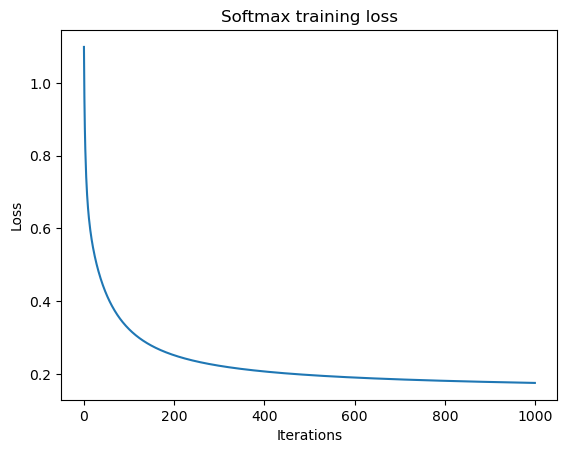

In [38]:
# plot loss history
plt.plot(loss_history)
plt.title("Softmax training loss")
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

In [39]:
def softmax_predict(X, W, b):
    Z = X @ W + b
    P = softmax(Z)
    return np.argmax(P, axis=1)

In [40]:
# Quick test 
y_pred = softmax_predict(X, W, b)
acc = (y_pred == y).mean()
print("Training accuracy:", acc)
print("Final loss:", loss_history[-1])

Training accuracy: 0.9333333333333333
Final loss: 0.17554824153041024


### Step 8 : Decision regions 

The decision regions show how the trained model divides the feature space into each class and the assignment of each instance to the class with the highest predicted probabilities. 

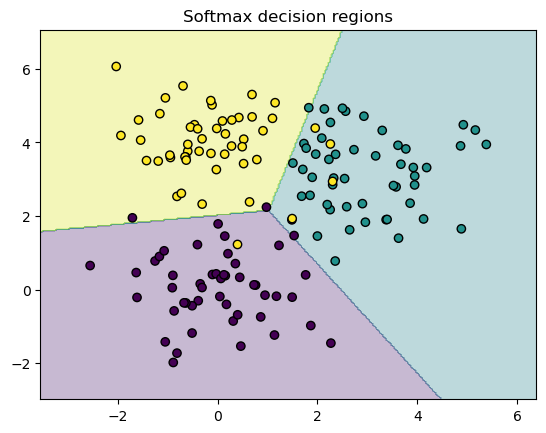

In [41]:
x0_min, x0_max = X[:,0].min()-1, X[:,0].max()+1
x1_min, x1_max = X[:,1].min()-1, X[:,1].max()+1

x0, x1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 300),
    np.linspace(x1_min, x1_max, 300)
)

grid = np.c_[x0.ravel(),x1.ravel()]
Z = softmax_predict(grid, W, b).reshape(x0.shape)

plt.contourf(x0, x1, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title('Softmax decision regions')
plt.show()